PRAKTIKUM 6.1: SIMULASI DEGRADASI CITRA


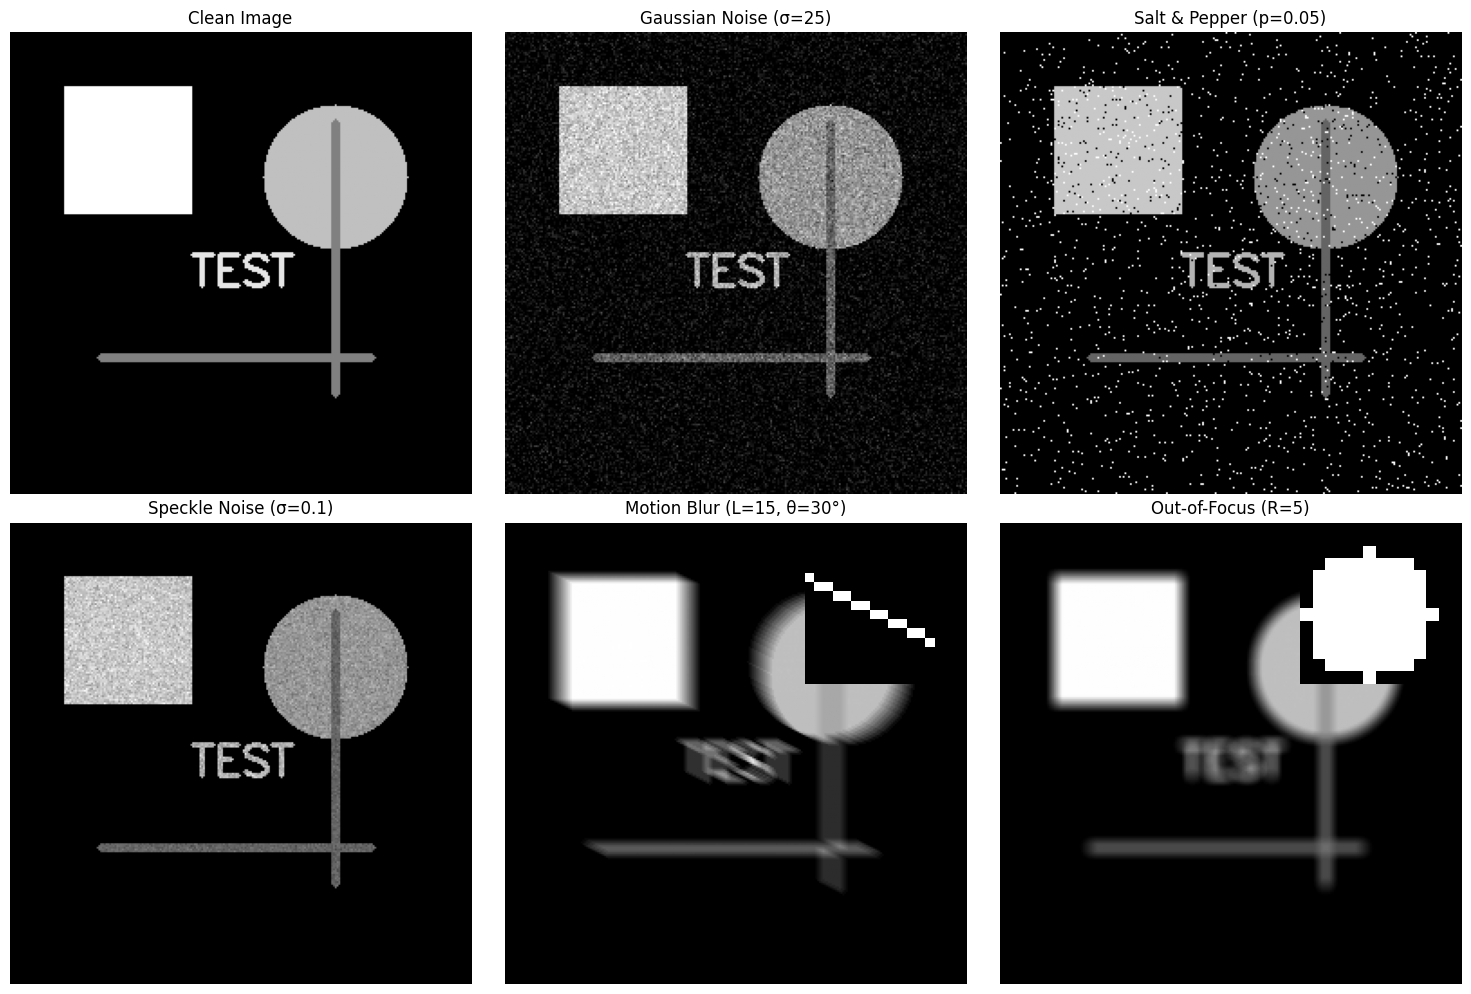


DEGRADATION METRICS COMPARISON
------------------------------------------------------------
Degradation Type          Mean       Std Dev    PSNR (dB)   
------------------------------------------------------------
Gaussian Noise (σ=25)     37.50      63.63      22.55       
Salt & Pepper (p=0.05)    34.22      72.53      16.58       
Speckle Noise (σ=0.1)     29.49      65.40      30.97       
Motion Blur (L=15, θ=30°) 29.43      59.65      21.88       
Out-of-Focus (R=5)        29.42      60.05      22.48       


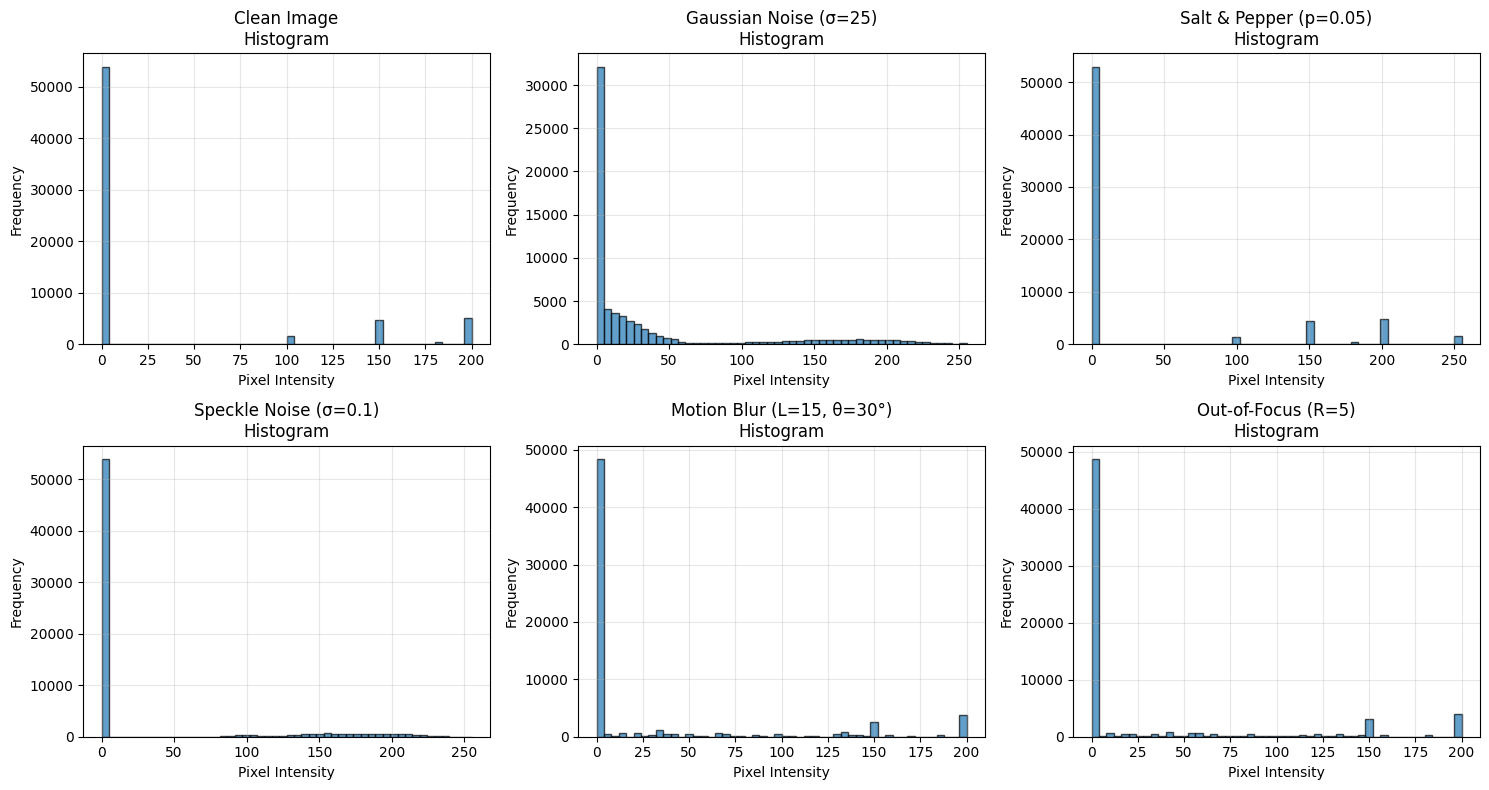


PRAKTIKUM 6.2: INVERSE FILTER VS WIENER FILTER


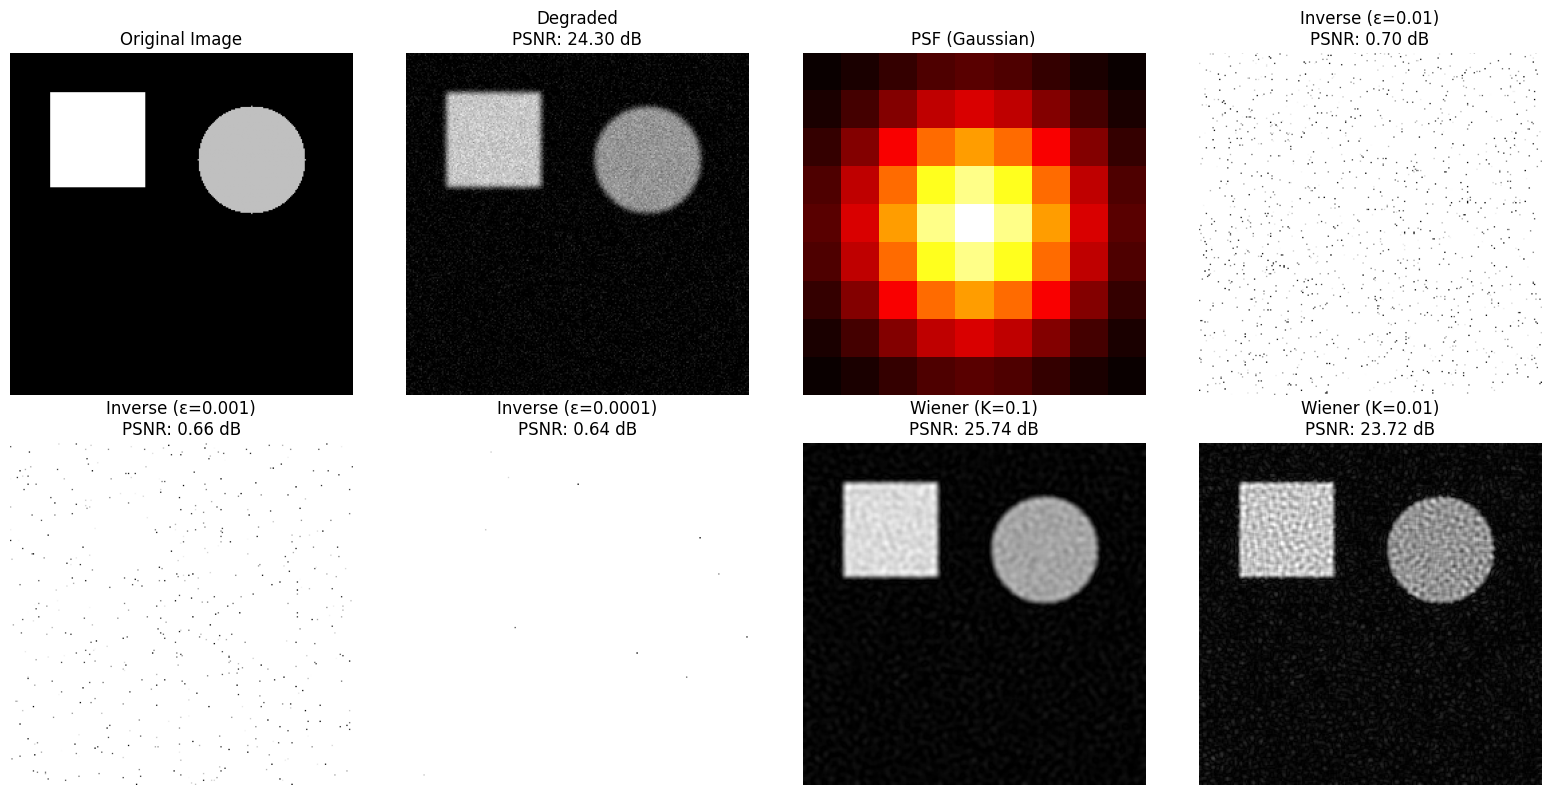


RESTORATION PERFORMANCE COMPARISON
----------------------------------------------------------------------
Method               PSNR (dB)    Improvement (dB) MSE         
----------------------------------------------------------------------
Inverse (ε=0.01)     0.70         -23.60          55321.50    
Inverse (ε=0.001)    0.66         -23.64          55807.05    
Inverse (ε=0.0001)   0.64         -23.66          56108.33    
Wiener (K=0.1)       25.74        1.45            173.23      
Wiener (K=0.01)      23.72        -0.58           275.92      
Wiener (K=0.001)     13.43        -10.87          2954.92     

FREQUENCY DOMAIN ANALYSIS
----------------------------------------


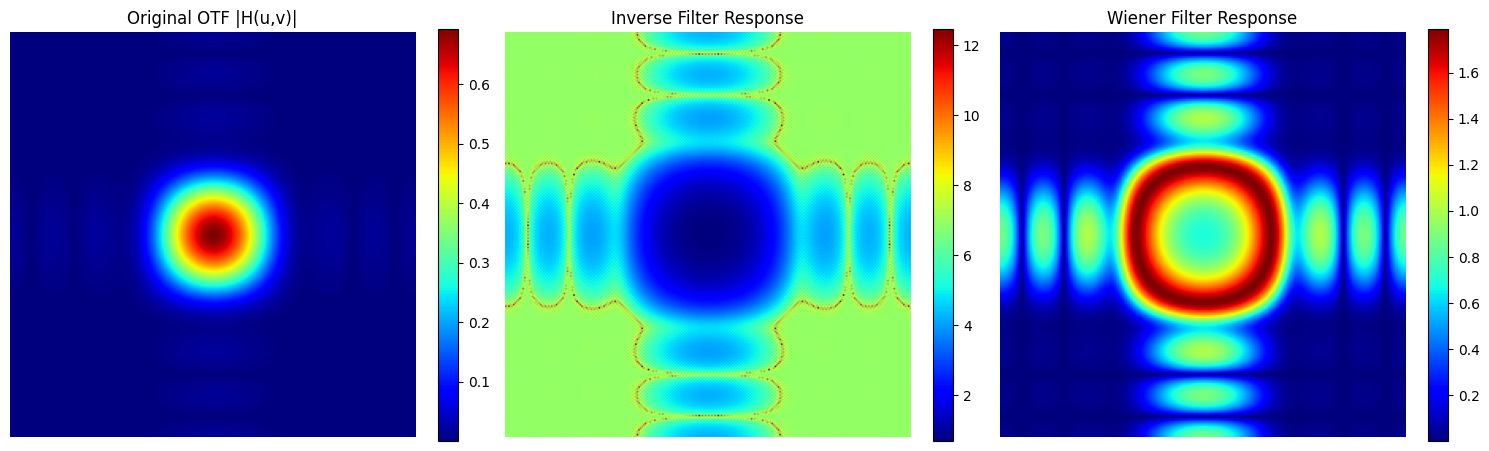

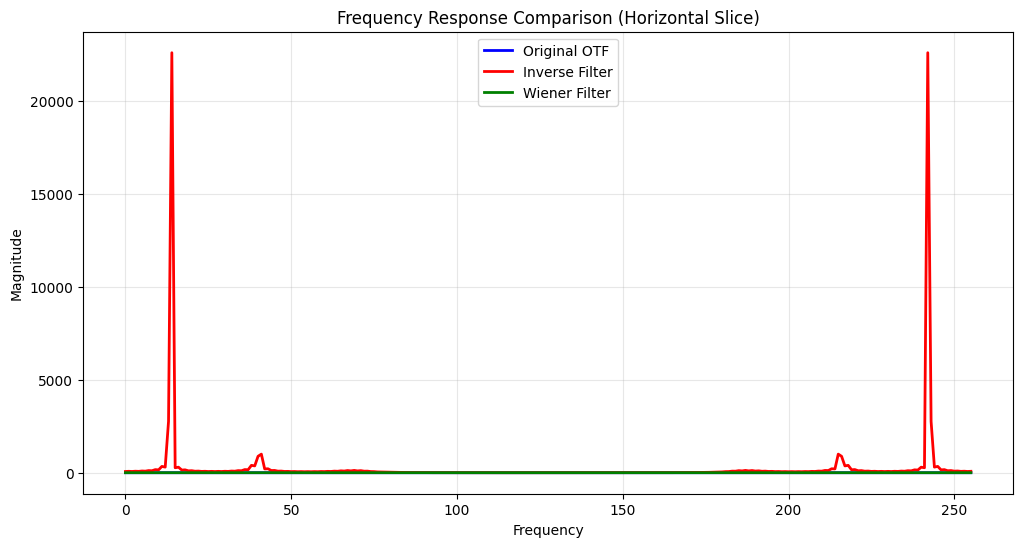


PRAKTIKUM 6.3: MOTION BLUR ESTIMATION DAN DEBLURRING
True Blur Parameters: Length = 21, Angle = 30°
Estimated Parameters: Length = 127, Angle = 117.0°
Iteration 5: MSE = 86.39
Iteration 10: MSE = 75.22
Iteration 15: MSE = 69.81
Iteration 20: MSE = 66.67


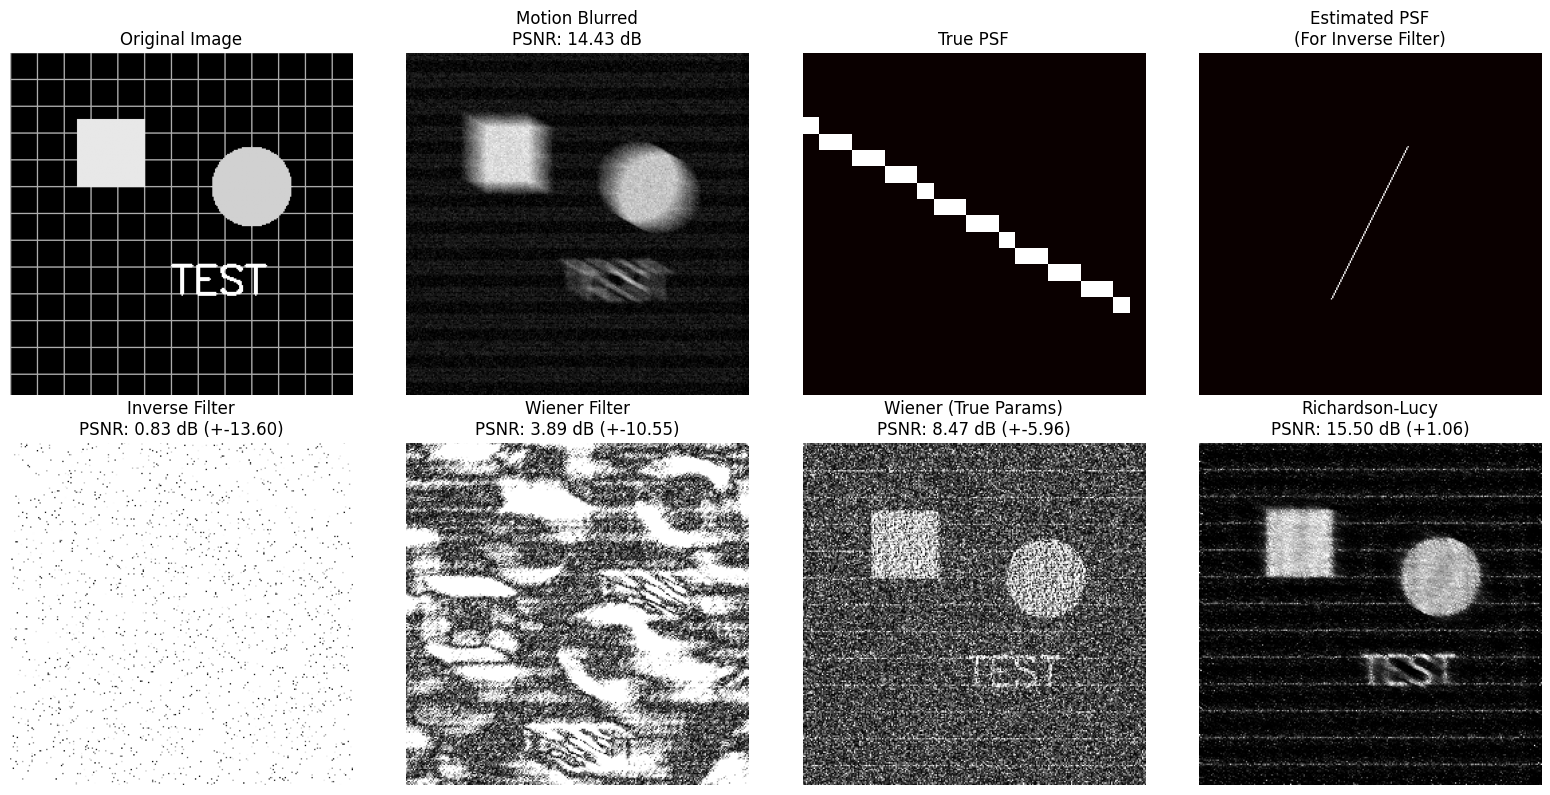


DEBLURRING PERFORMANCE COMPARISON
--------------------------------------------------------------------------------
Method                    PSNR (dB)    Improvement (dB) SSIM         MSE         
--------------------------------------------------------------------------------
Inverse Filter            0.83         -13.60          0.024        53670.31    
Wiener Filter             3.89         -10.55          0.001        26569.56    
Wiener (True Params)      8.47         -5.96           0.008        9241.14     
Richardson-Lucy           15.50        1.06            0.201        1832.72     

FREQUENCY SPECTRUM ANALYSIS
----------------------------------------


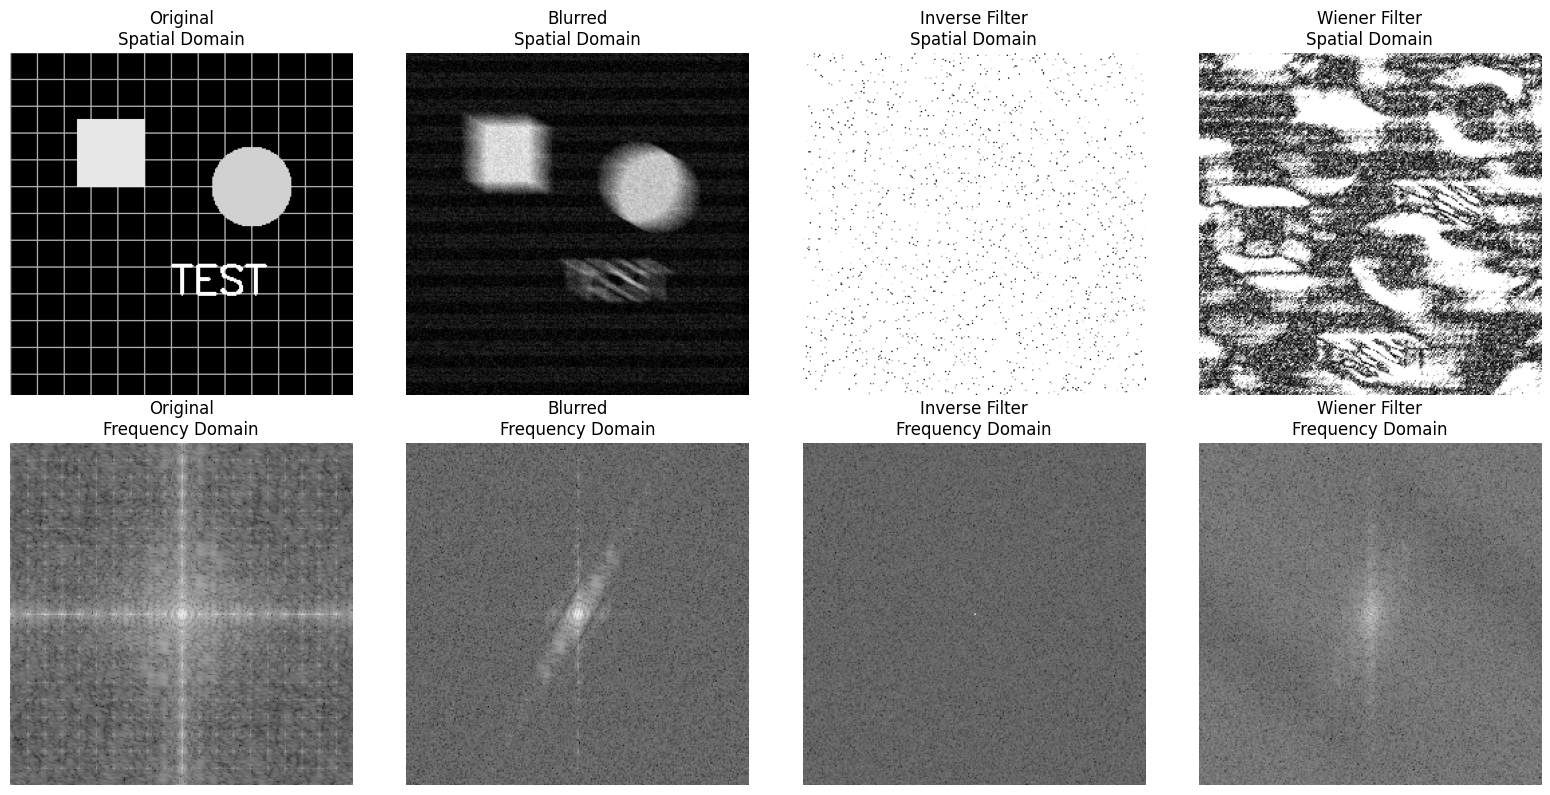


INTENSITY PROFILE ANALYSIS
----------------------------------------


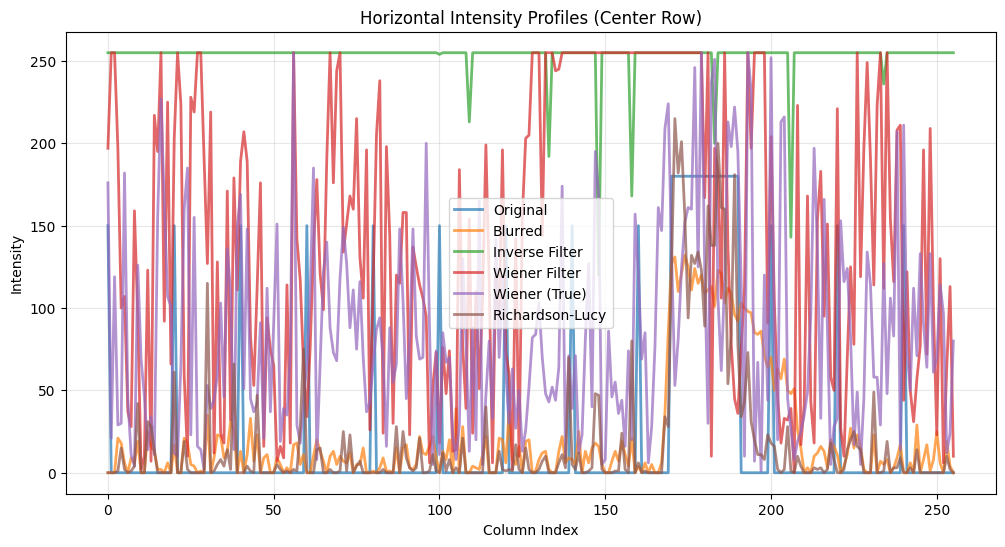

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft2, ifft2, fftshift, ifftshift

def praktikum_6_1():
    """
    Simulasi degradasi citra dengan berbagai jenis noise
    """
    print("PRAKTIKUM 6.1: SIMULASI DEGRADASI CITRA")
    print("=" * 50)

    # Load atau buat citra test
    def create_test_image():
        """Create synthetic test image with various features"""
        img = np.zeros((256, 256), dtype=np.uint8)

        # Add different patterns
        cv2.rectangle(img, (30, 30), (100, 100), 200, -1)  # Bright rectangle
        cv2.circle(img, (180, 80), 40, 150, -1)  # Medium circle
        cv2.line(img, (50, 180), (200, 180), 100, 3)  # Horizontal line
        cv2.line(img, (180, 50), (180, 200), 100, 3)  # Vertical line

        # Add text for detail
        cv2.putText(img, 'TEST', (100, 140), cv2.FONT_HERSHEY_SIMPLEX,
                   0.8, 180, 2)

        return img

    # Function untuk menambahkan berbagai jenis noise
    def add_gaussian_noise(image, mean=0, sigma=25):
        """Add Gaussian noise"""
        noise = np.random.normal(mean, sigma, image.shape)
        noisy = np.clip(image.astype(float) + noise, 0, 255)
        return noisy.astype(np.uint8)

    def add_salt_pepper_noise(image, prob=0.05):
        """Add salt and pepper noise"""
        noisy = image.copy()
        total_pixels = image.size

        # Salt noise (white)
        num_salt = int(total_pixels * prob / 2)
        salt_coords = [np.random.randint(0, i, num_salt) for i in image.shape]
        noisy[salt_coords[0], salt_coords[1]] = 255

        # Pepper noise (black)
        num_pepper = int(total_pixels * prob / 2)
        pepper_coords = [np.random.randint(0, i, num_pepper) for i in image.shape]
        noisy[pepper_coords[0], pepper_coords[1]] = 0

        return noisy

    def add_speckle_noise(image, sigma=0.1):
        """Add multiplicative speckle noise"""
        noise = np.random.normal(1, sigma, image.shape)
        noisy = np.clip(image.astype(float) * noise, 0, 255)
        return noisy.astype(np.uint8)

    def add_motion_blur(image, length=15, angle=0):
        """Add motion blur degradation"""
        # Create motion blur kernel
        kernel = np.zeros((length, length))

        # Center of kernel
        center = length // 2

        # Draw line based on angle
        angle_rad = np.deg2rad(angle)
        x_start = int(center - (length/2) * np.cos(angle_rad))
        y_start = int(center - (length/2) * np.sin(angle_rad))
        x_end = int(center + (length/2) * np.cos(angle_rad))
        y_end = int(center + (length/2) * np.sin(angle_rad))

        cv2.line(kernel, (x_start, y_start), (x_end, y_end), 1, 1)

        # Normalize kernel
        kernel = kernel / np.sum(kernel)

        # Apply convolution
        blurred = cv2.filter2D(image.astype(float), -1, kernel)

        return np.clip(blurred, 0, 255).astype(np.uint8), kernel

    def add_out_of_focus_blur(image, radius=5):
        """Add out-of-focus blur"""
        # Create circular kernel
        kernel_size = 2 * radius + 1
        kernel = np.zeros((kernel_size, kernel_size))

        # Draw circle
        center = radius
        y, x = np.ogrid[-center:kernel_size-center, -center:kernel_size-center]
        mask = x**2 + y**2 <= radius**2
        kernel[mask] = 1

        # Normalize
        kernel = kernel / np.sum(kernel)

        # Apply blur
        blurred = cv2.filter2D(image.astype(float), -1, kernel)

        return np.clip(blurred, 0, 255).astype(np.uint8), kernel

    # Create clean image
    clean_img = create_test_image()

    # Apply different degradations
    degradations = {
        'Clean Image': (clean_img, None),
        'Gaussian Noise (σ=25)': (add_gaussian_noise(clean_img, 0, 25), None),
        'Salt & Pepper (p=0.05)': (add_salt_pepper_noise(clean_img, 0.05), None),
        'Speckle Noise (σ=0.1)': (add_speckle_noise(clean_img, 0.1), None),
        'Motion Blur (L=15, θ=30°)': add_motion_blur(clean_img, 15, 30),
        'Out-of-Focus (R=5)': add_out_of_focus_blur(clean_img, 5)
    }

    # Display results
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()

    for idx, (title, degradation) in enumerate(degradations.items()):
        if isinstance(degradation, tuple) and len(degradation) == 2:
            degraded_img, kernel = degradation
        else:
            degraded_img = degradation
            kernel = None

        axes[idx].imshow(degraded_img, cmap='gray')
        axes[idx].set_title(title)
        axes[idx].axis('off')

        # Display kernel jika ada
        if kernel is not None and idx >= 4:  # Untuk motion blur dan out-of-focus
            # Create inset untuk kernel
            inset_ax = axes[idx].inset_axes([0.65, 0.65, 0.3, 0.3])
            inset_ax.imshow(kernel, cmap='gray')
            inset_ax.set_title('PSF')
            inset_ax.axis('off')

    plt.tight_layout()
    plt.show()

    # Calculate and display metrics
    print("\nDEGRADATION METRICS COMPARISON")
    print("-" * 60)
    print(f"{'Degradation Type':<25} {'Mean':<10} {'Std Dev':<10} {'PSNR (dB)':<12}")
    print("-" * 60)

    for title, degradation in degradations.items():
        if title == 'Clean Image':
            continue

        if isinstance(degradation, tuple) and len(degradation) == 2:
            degraded_img, _ = degradation
        else:
            degraded_img = degradation

        # Calculate metrics
        mean_val = np.mean(degraded_img)
        std_val = np.std(degraded_img)

        # Calculate PSNR relative to clean image
        mse = np.mean((clean_img.astype(float) - degraded_img.astype(float)) ** 2)
        psnr = 10 * np.log10(255**2 / mse) if mse > 0 else float('inf')

        print(f"{title:<25} {mean_val:<10.2f} {std_val:<10.2f} {psnr:<12.2f}")

    # Histogram analysis
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.ravel()

    for idx, (title, degradation) in enumerate(degradations.items()):
        if isinstance(degradation, tuple) and len(degradation) == 2:
            degraded_img, _ = degradation
        else:
            degraded_img = degradation

        axes[idx].hist(degraded_img.ravel(), bins=50, alpha=0.7, edgecolor='black')
        axes[idx].set_title(f'{title}\nHistogram')
        axes[idx].set_xlabel('Pixel Intensity')
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return clean_img, degradations

clean_img, degradations = praktikum_6_1()

def praktikum_6_2():
    """
    Perbandingan Inverse Filter dan Wiener Filter untuk restorasi citra
    """
    print("\nPRAKTIKUM 6.2: INVERSE FILTER VS WIENER FILTER")
    print("=" * 50)

    # Buat citra terdegradasi dengan blur dan noise
    def create_degraded_image():
        """Create image degraded with blur and noise"""
        # Create test pattern
        img = np.zeros((256, 256), dtype=np.uint8)
        cv2.rectangle(img, (30, 30), (100, 100), 200, -1)
        cv2.circle(img, (180, 80), 40, 150, -1)

        # Add Gaussian blur
        blurred = cv2.GaussianBlur(img, (9, 9), 2)

        # Add Gaussian noise
        noise = np.random.normal(0, 15, blurred.shape)
        degraded = np.clip(blurred + noise, 0, 255)

        return img, degraded.astype(np.uint8)

    # Implementasi filter restorasi
    def inverse_filter(degraded, psf, epsilon=1e-3):
        """Inverse filtering with regularization"""
        # Padding untuk menghindari boundary effects
        pad_size = psf.shape[0] // 2
        padded = cv2.copyMakeBorder(degraded, pad_size, pad_size,
                                   pad_size, pad_size, cv2.BORDER_REFLECT)

        # Transform ke domain frekuensi
        G = np.fft.fft2(padded.astype(float))

        # Buat PSF dengan size yang sama
        psf_padded = np.zeros_like(padded, dtype=float)
        psf_center_y, psf_center_x = psf.shape[0]//2, psf.shape[1]//2
        pad_center_y, pad_center_x = padded.shape[0]//2, padded.shape[1]//2

        y_start = pad_center_y - psf_center_y
        x_start = pad_center_x - psf_center_x
        psf_padded[y_start:y_start+psf.shape[0], x_start:x_start+psf.shape[1]] = psf

        # Shift PSF untuk centering
        psf_padded = np.fft.ifftshift(psf_padded)

        # Compute OTF
        H = np.fft.fft2(psf_padded)

        # Regularized inverse filter
        H_reg = H + epsilon

        # Apply inverse filter
        F_hat = G / H_reg

        # Inverse transform
        restored_padded = np.abs(np.fft.ifft2(F_hat))

        # Remove padding
        restored = restored_padded[pad_size:-pad_size, pad_size:-pad_size]

        return np.clip(restored, 0, 255).astype(np.uint8)

    def wiener_filter(degraded, psf, K=0.01):
        """Wiener filter implementation"""
        # Padding
        pad_size = psf.shape[0] // 2
        padded = cv2.copyMakeBorder(degraded, pad_size, pad_size,
                                   pad_size, pad_size, cv2.BORDER_REFLECT)

        # Transform ke domain frekuensi
        G = np.fft.fft2(padded.astype(float))

        # Buat PSF dengan size yang sama
        psf_padded = np.zeros_like(padded, dtype=float)
        psf_center_y, psf_center_x = psf.shape[0]//2, psf.shape[1]//2
        pad_center_y, pad_center_x = padded.shape[0]//2, padded.shape[1]//2

        y_start = pad_center_y - psf_center_y
        x_start = pad_center_x - psf_center_x
        psf_padded[y_start:y_start+psf.shape[0], x_start:x_start+psf.shape[1]] = psf

        # Shift PSF
        psf_padded = np.fft.ifftshift(psf_padded)

        # Compute OTF
        H = np.fft.fft2(psf_padded)
        H_conj = np.conj(H)
        H_abs_sq = np.abs(H) ** 2

        # Wiener filter
        W = H_conj / (H_abs_sq + K)

        # Apply filter
        F_hat = G * W

        # Inverse transform
        restored_padded = np.abs(np.fft.ifft2(F_hat))

        # Remove padding
        restored = restored_padded[pad_size:-pad_size, pad_size:-pad_size]

        return np.clip(restored, 0, 255).astype(np.uint8)

    # Generate PSF (Gaussian blur kernel)
    def create_gaussian_psf(size=9, sigma=2):
        """Create Gaussian PSF"""
        psf = np.zeros((size, size))
        center = size // 2

        for i in range(size):
            for j in range(size):
                x = i - center
                y = j - center
                psf[i, j] = np.exp(-(x**2 + y**2) / (2 * sigma**2))

        psf = psf / np.sum(psf)
        return psf

    # Create test data
    original, degraded = create_degraded_image()
    psf = create_gaussian_psf(9, 2)

    # Apply different restoration filters dengan berbagai parameter
    restorations = {}

    # Inverse filter dengan berbagai epsilon
    for eps in [1e-2, 1e-3, 1e-4]:
        restored = inverse_filter(degraded, psf, epsilon=eps)
        restorations[f'Inverse (ε={eps})'] = restored

    # Wiener filter dengan berbagai K
    for K in [0.1, 0.01, 0.001]:
        restored = wiener_filter(degraded, psf, K=K)
        restorations[f'Wiener (K={K})'] = restored

    # Visualisasi hasil
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()

    # Original dan degraded
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(degraded, cmap='gray')

    # Calculate PSNR untuk degraded
    mse_degraded = np.mean((original.astype(float) - degraded.astype(float)) ** 2)
    psnr_degraded = 10 * np.log10(255**2 / mse_degraded)

    axes[1].set_title(f'Degraded\nPSNR: {psnr_degraded:.2f} dB')
    axes[1].axis('off')

    # Display PSF
    axes[2].imshow(psf, cmap='hot')
    axes[2].set_title('PSF (Gaussian)')
    axes[2].axis('off')

    # Display restoration results
    results_list = list(restorations.items())
    for idx in range(5):
        title, restored = results_list[idx]

        # Calculate PSNR
        mse = np.mean((original.astype(float) - restored.astype(float)) ** 2)
        psnr = 10 * np.log10(255**2 / mse)

        axes[idx+3].imshow(restored, cmap='gray')
        axes[idx+3].set_title(f'{title}\nPSNR: {psnr:.2f} dB')
        axes[idx+3].axis('off')

    plt.tight_layout()
    plt.show()

    # Quantitative comparison
    print("\nRESTORATION PERFORMANCE COMPARISON")
    print("-" * 70)
    print(f"{'Method':<20} {'PSNR (dB)':<12} {'Improvement (dB)':<15} {'MSE':<12}")
    print("-" * 70)

    baseline_psnr = psnr_degraded

    for title, restored in restorations.items():
        mse = np.mean((original.astype(float) - restored.astype(float)) ** 2)
        psnr = 10 * np.log10(255**2 / mse)
        improvement = psnr - baseline_psnr

        print(f"{title:<20} {psnr:<12.2f} {improvement:<15.2f} {mse:<12.2f}")

    # Frequency domain analysis
    print("\nFREQUENCY DOMAIN ANALYSIS")
    print("-" * 40)

    # Analyze frequency response of filters
    def analyze_frequency_response(psf, epsilon=1e-3, K=0.01):
        """Analyze frequency response of filters"""
        size = 256
        psf_padded = np.zeros((size, size))
        center = size // 2
        psf_center = psf.shape[0] // 2

        # Place PSF in center
        y_start = center - psf_center
        x_start = center - psf_center
        psf_padded[y_start:y_start+psf.shape[0], x_start:x_start+psf.shape[1]] = psf

        # Compute OTF
        H = np.fft.fft2(psf_padded)
        H = np.fft.fftshift(H)

        # Inverse filter response
        H_inv = 1 / (H + epsilon)

        # Wiener filter response
        H_conj = np.conj(H)
        H_abs_sq = np.abs(H) ** 2
        H_wiener = H_conj / (H_abs_sq + K)

        return np.abs(H), np.abs(H_inv), np.abs(H_wiener)

    H, H_inv, H_wiener = analyze_frequency_response(psf)

    # Plot frequency responses
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original OTF
    im1 = axes[0].imshow(np.log(1 + np.abs(H)), cmap='jet')
    axes[0].set_title('Original OTF |H(u,v)|')
    axes[0].axis('off')
    plt.colorbar(im1, ax=axes[0], fraction=0.046)

    # Inverse filter response
    im2 = axes[1].imshow(np.log(1 + np.abs(H_inv)), cmap='jet')
    axes[1].set_title('Inverse Filter Response')
    axes[1].axis('off')
    plt.colorbar(im2, ax=axes[1], fraction=0.046)

    # Wiener filter response
    im3 = axes[2].imshow(np.log(1 + np.abs(H_wiener)), cmap='jet')
    axes[2].set_title('Wiener Filter Response')
    axes[2].axis('off')
    plt.colorbar(im3, ax=axes[2], fraction=0.046)

    plt.tight_layout()
    plt.show()

    # Perbandingan cross-section
    center = 128
    H_slice = np.abs(H)[center, :]
    H_inv_slice = np.abs(H_inv)[center, :]
    H_wiener_slice = np.abs(H_wiener)[center, :]

    plt.figure(figsize=(12, 6))
    plt.plot(H_slice, 'b-', linewidth=2, label='Original OTF')
    plt.plot(H_inv_slice, 'r-', linewidth=2, label='Inverse Filter')
    plt.plot(H_wiener_slice, 'g-', linewidth=2, label='Wiener Filter')
    plt.title('Frequency Response Comparison (Horizontal Slice)')
    plt.xlabel('Frequency')
    plt.ylabel('Magnitude')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return original, degraded, restorations

original, degraded, restorations = praktikum_6_2()

def praktikum_6_3():
    """
    Motion blur estimation dan teknik deblurring
    """
    print("\nPRAKTIKUM 6.3: MOTION BLUR ESTIMATION DAN DEBLURRING")
    print("=" * 60)

    # Generate motion blurred image
    def create_motion_blurred_image():
        """Create image with simulated motion blur"""
        # Load or create test image
        img = np.zeros((256, 256), dtype=np.uint8)

        # Create detailed pattern
        for i in range(0, 256, 20):
            cv2.line(img, (i, 0), (i, 255), 150, 1)
            cv2.line(img, (0, i), (255, i), 150, 1)

        # Add objects
        cv2.rectangle(img, (50, 50), (100, 100), 200, -1)
        cv2.circle(img, (180, 100), 30, 180, -1)

        # Text for high frequency content
        cv2.putText(img, 'TEST', (120, 180), cv2.FONT_HERSHEY_SIMPLEX,
                   1, 220, 2)

        # Create motion blur PSF
        length = 21
        angle = 30  # degrees

        psf = np.zeros((length, length))
        center = length // 2
        angle_rad = np.deg2rad(angle)

        # Draw line for motion blur
        x_start = int(center - (length/2) * np.cos(angle_rad))
        y_start = int(center - (length/2) * np.sin(angle_rad))
        x_end = int(center + (length/2) * np.cos(angle_rad))
        y_end = int(center + (length/2) * np.sin(angle_rad))

        cv2.line(psf, (x_start, y_start), (x_end, y_end), 1, 1)
        psf = psf / np.sum(psf)

        # Apply motion blur
        blurred = cv2.filter2D(img.astype(float), -1, psf)

        # Add noise
        noise = np.random.normal(0, 10, blurred.shape)
        blurred_noisy = np.clip(blurred + noise, 0, 255)

        return img, blurred_noisy.astype(np.uint8), psf

    # Motion blur parameter estimation
    def estimate_motion_blur_parameters(image):
        """
        Estimate motion blur length and angle from image
        using Radon transform or Hough transform
        """
        # Convert to binary edge image
        edges = cv2.Canny(image, 50, 150)

        # Method 1: Using Hough Line Transform
        lines = cv2.HoughLines(edges, 1, np.pi/180, threshold=100)

        angles = []
        if lines is not None:
            for line in lines[:5]:  # Take top 5 lines
                rho, theta = line[0]
                angles.append(np.degrees(theta))

        # Method 2: Using image spectrum (cepstrum analysis)
        # Compute log spectrum
        f = np.fft.fft2(image.astype(float))
        fshift = np.fft.fftshift(f)
        magnitude_spectrum = np.log(1 + np.abs(fshift))

        # Estimate angle from spectrum (simplified)
        # In practice, use more sophisticated methods

        if angles:
            estimated_angle = np.mean(angles) % 180
        else:
            estimated_angle = 0

        # Estimate length from autocorrelation
        autocorr = signal.correlate2d(image, image, mode='same')
        autocorr = autocorr / np.max(autocorr)

        # Find main lobe width
        center = autocorr.shape[0] // 2
        profile = autocorr[center, :]

        # Find FWHM (full width at half maximum)
        half_max = 0.5
        above_half = profile > half_max
        if np.any(above_half):
            indices = np.where(above_half)[0]
            fwhm = indices[-1] - indices[0]
            estimated_length = fwhm // 2
        else:
            estimated_length = 15

        return estimated_length, estimated_angle

    # Motion deblurring techniques
    def motion_deblur_inverse(image, length, angle, epsilon=1e-3):
        """Deblur using inverse filtering with estimated PSF"""
        # Create estimated PSF
        psf_size = max(31, 2 * length + 1)
        psf = np.zeros((psf_size, psf_size))
        center = psf_size // 2
        angle_rad = np.deg2rad(angle)

        # Draw line
        x_start = int(center - (length/2) * np.cos(angle_rad))
        y_start = int(center - (length/2) * np.sin(angle_rad))
        x_end = int(center + (length/2) * np.cos(angle_rad))
        y_end = int(center + (length/2) * np.sin(angle_rad))

        cv2.line(psf, (x_start, y_start), (x_end, y_end), 1, 1)
        psf = psf / np.sum(psf)

        # Apply inverse filter
        pad_size = psf_size // 2
        padded = cv2.copyMakeBorder(image, pad_size, pad_size,
                                   pad_size, pad_size, cv2.BORDER_REFLECT)

        # FFT
        G = np.fft.fft2(padded.astype(float))

        # Create PSF in frequency domain
        psf_padded = np.zeros_like(padded, dtype=float)
        psf_center = psf_size // 2
        pad_center = padded.shape[0] // 2

        y_start = pad_center - psf_center
        x_start = pad_center - psf_center
        psf_padded[y_start:y_start+psf_size, x_start:x_start+psf_size] = psf
        psf_padded = np.fft.ifftshift(psf_padded)

        H = np.fft.fft2(psf_padded)

        # Regularized inverse
        H_reg = H + epsilon
        F_hat = G / H_reg

        # Inverse FFT
        restored_padded = np.abs(np.fft.ifft2(F_hat))
        restored = restored_padded[pad_size:-pad_size, pad_size:-pad_size]

        return np.clip(restored, 0, 255).astype(np.uint8), psf

    def motion_deblur_wiener(image, length, angle, K=0.001):
        """Deblur using Wiener filter"""
        # Create PSF
        psf_size = max(31, 2 * length + 1)
        psf = np.zeros((psf_size, psf_size))
        center = psf_size // 2
        angle_rad = np.deg2rad(angle)

        # Draw line
        x_start = int(center - (length/2) * np.cos(angle_rad))
        y_start = int(center - (length/2) * np.sin(angle_rad))
        x_end = int(center + (length/2) * np.cos(angle_rad))
        y_end = int(center + (length/2) * np.sin(angle_rad))

        cv2.line(psf, (x_start, y_start), (x_end, y_end), 1, 1)
        psf = psf / np.sum(psf)

        # Apply Wiener filter
        pad_size = psf_size // 2
        padded = cv2.copyMakeBorder(image, pad_size, pad_size,
                                   pad_size, pad_size, cv2.BORDER_REFLECT)

        # FFT
        G = np.fft.fft2(padded.astype(float))

        # Create PSF in frequency domain
        psf_padded = np.zeros_like(padded, dtype=float)
        psf_center = psf_size // 2
        pad_center = padded.shape[0] // 2

        y_start = pad_center - psf_center
        x_start = pad_center - psf_center
        psf_padded[y_start:y_start+psf_size, x_start:x_start+psf_size] = psf
        psf_padded = np.fft.ifftshift(psf_padded)

        H = np.fft.fft2(psf_padded)
        H_conj = np.conj(H)
        H_abs_sq = np.abs(H) ** 2

        # Wiener filter
        W = H_conj / (H_abs_sq + K)
        F_hat = G * W

        # Inverse FFT
        restored_padded = np.abs(np.fft.ifft2(F_hat))
        restored = restored_padded[pad_size:-pad_size, pad_size:-pad_size]

        return np.clip(restored, 0, 255).astype(np.uint8), psf

    def richardson_lucy_deblur(image, psf, iterations=20):
        """Richardson-Lucy deconvolution"""
        image = image.astype(np.float32)
        psf = psf.astype(np.float32)

        # Initialize with blurred image
        estimate = image.copy()

        # Flip PSF
        psf_flipped = np.flip(psf)

        for i in range(iterations):
            # Compute current estimate of blurred image
            conv = cv2.filter2D(estimate, -1, psf)

            # Avoid division by zero
            conv = np.where(conv == 0, 1e-8, conv)

            # Compute ratio
            ratio = image / conv

            # Update estimate
            correction = cv2.filter2D(ratio, -1, psf_flipped)
            estimate = estimate * correction

            # Clip to valid range
            estimate = np.clip(estimate, 0, 255)

            # Optional: Print progress
            if (i + 1) % 5 == 0:
                mse = np.mean((image - conv) ** 2)
                print(f"Iteration {i+1}: MSE = {mse:.2f}")

        return estimate.astype(np.uint8)

    # Generate test data
    original, blurred, true_psf = create_motion_blurred_image()

    # Estimate blur parameters
    estimated_length, estimated_angle = estimate_motion_blur_parameters(blurred)
    true_length = 21
    true_angle = 30

    print(f"True Blur Parameters: Length = {true_length}, Angle = {true_angle}°")
    print(f"Estimated Parameters: Length = {estimated_length}, Angle = {estimated_angle:.1f}°")

    # Apply different deblurring methods
    deblurring_results = {}

    # 1. Inverse filter dengan estimated parameters
    inv_deblurred, est_psf_inv = motion_deblur_inverse(blurred, estimated_length,
                                                      estimated_angle, epsilon=1e-3)
    deblurring_results['Inverse Filter'] = inv_deblurred

    # 2. Wiener filter dengan estimated parameters
    wiener_deblurred, est_psf_wiener = motion_deblur_wiener(blurred, estimated_length,
                                                           estimated_angle, K=0.001)
    deblurring_results['Wiener Filter'] = wiener_deblurred

    # 3. Wiener filter dengan true parameters (sebagai baseline)
    wiener_true, _ = motion_deblur_wiener(blurred, true_length, true_angle, K=0.001)
    deblurring_results['Wiener (True Params)'] = wiener_true

    # 4. Richardson-Lucy deconvolution
    rl_deblurred = richardson_lucy_deblur(blurred, true_psf, iterations=20)
    deblurring_results['Richardson-Lucy'] = rl_deblurred

    # Visualisasi hasil
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))

    # Row 1
    axes[0,0].imshow(original, cmap='gray')
    axes[0,0].set_title('Original Image')
    axes[0,0].axis('off')

    axes[0,1].imshow(blurred, cmap='gray')
    mse_blurred = np.mean((original.astype(float) - blurred.astype(float)) ** 2)
    psnr_blurred = 10 * np.log10(255**2 / mse_blurred)
    axes[0,1].set_title(f'Motion Blurred\nPSNR: {psnr_blurred:.2f} dB')
    axes[0,1].axis('off')

    axes[0,2].imshow(true_psf, cmap='hot')
    axes[0,2].set_title('True PSF')
    axes[0,2].axis('off')

    axes[0,3].imshow(est_psf_inv, cmap='hot')
    axes[0,3].set_title('Estimated PSF\n(For Inverse Filter)')
    axes[0,3].axis('off')

    # Row 2: Deblurring results
    methods = list(deblurring_results.items())
    for idx, (method_name, result) in enumerate(methods):
        # Calculate metrics
        mse = np.mean((original.astype(float) - result.astype(float)) ** 2)
        psnr = 10 * np.log10(255**2 / mse)
        improvement = psnr - psnr_blurred

        axes[1, idx].imshow(result, cmap='gray')
        axes[1, idx].set_title(f'{method_name}\nPSNR: {psnr:.2f} dB (+{improvement:.2f})')
        axes[1, idx].axis('off')

    plt.tight_layout()
    plt.show()

    # Quantitative analysis
    print("\nDEBLURRING PERFORMANCE COMPARISON")
    print("-" * 80)
    print(f"{'Method':<25} {'PSNR (dB)':<12} {'Improvement (dB)':<15} {'SSIM':<12} {'MSE':<12}")
    print("-" * 80)

    # Calculate SSIM
    def calculate_ssim(img1, img2):
        """Simplified SSIM calculation"""
        C1 = (0.01 * 255) ** 2
        C2 = (0.03 * 255) ** 2

        img1 = img1.astype(np.float32)
        img2 = img2.astype(np.float32)

        mu1 = cv2.GaussianBlur(img1, (11, 11), 1.5)
        mu2 = cv2.GaussianBlur(img2, (11, 11), 1.5)

        mu1_sq = mu1 ** 2
        mu2_sq = mu2 ** 2
        mu1_mu2 = mu1 * mu2

        sigma1_sq = cv2.GaussianBlur(img1 ** 2, (11, 11), 1.5) - mu1_sq
        sigma2_sq = cv2.GaussianBlur(img2 ** 2, (11, 11), 1.5) - mu2_sq
        sigma12 = cv2.GaussianBlur(img1 * img2, (11, 11), 1.5) - mu1_mu2

        ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / \
                   ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))

        return np.mean(ssim_map)

    baseline_ssim = calculate_ssim(original, blurred)

    for method_name, result in deblurring_results.items():
        mse = np.mean((original.astype(float) - result.astype(float)) ** 2)
        psnr = 10 * np.log10(255**2 / mse)
        improvement = psnr - psnr_blurred
        ssim = calculate_ssim(original, result)

        print(f"{method_name:<25} {psnr:<12.2f} {improvement:<15.2f} {ssim:<12.3f} {mse:<12.2f}")

    # Frequency spectrum analysis
    print("\nFREQUENCY SPECTRUM ANALYSIS")
    print("-" * 40)

    # Compute and display frequency spectra
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))

    images_to_analyze = [
        ('Original', original),
        ('Blurred', blurred),
        ('Inverse Filter', inv_deblurred),
        ('Wiener Filter', wiener_deblurred),
        ('Wiener (True)', wiener_true),
        ('Richardson-Lucy', rl_deblurred)
    ]

    for idx, (title, img) in enumerate(images_to_analyze[:4]):
        # Spatial domain
        axes[0, idx].imshow(img, cmap='gray')
        axes[0, idx].set_title(f'{title}\nSpatial Domain')
        axes[0, idx].axis('off')

        # Frequency domain (log magnitude)
        f = np.fft.fft2(img.astype(float))
        fshift = np.fft.fftshift(f)
        magnitude_spectrum = np.log(1 + np.abs(fshift))

        axes[1, idx].imshow(magnitude_spectrum, cmap='gray')
        axes[1, idx].set_title(f'{title}\nFrequency Domain')
        axes[1, idx].axis('off')

    plt.tight_layout()
    plt.show()

    # Profile analysis
    print("\nINTENSITY PROFILE ANALYSIS")
    print("-" * 40)

    # Take horizontal profile through center
    center_row = original.shape[0] // 2
    profiles = {}

    for title, img in images_to_analyze:
        profiles[title] = img[center_row, :]

    # Plot profiles
    plt.figure(figsize=(12, 6))
    for title, profile in profiles.items():
        plt.plot(profile, label=title, linewidth=2, alpha=0.7)

    plt.title('Horizontal Intensity Profiles (Center Row)')
    plt.xlabel('Column Index')
    plt.ylabel('Intensity')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return original, blurred, deblurring_results

original_motion, blurred_motion, deblurring_results = praktikum_6_3()